# 🎬 Análise da Relação entre Orçamento e Desempenho de Bilheteria

## ❓ Problema de Pesquisa
**Existe evidência de uma relação positiva entre o orçamento de um filme e seu desempenho de bilheteria?**

Este estudo busca investigar a relação entre o investimento realizado na produção de um filme e sua arrecadação global.

---

## 📊 Seleção das Variáveis

Para esta análise, foram selecionadas as seguintes colunas:

- **Budget (in $)**  
  Representa o orçamento do filme, ou seja, o valor total investido em sua produção (em dólares).

- **World Wide Sales (in $)**  
  Representa a receita total obtida pelo filme em bilheteria mundial.

---

## 📥 Carregamento dos Dados

In [45]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np

handle = "sanjeetsinghnaik/top-1000-highest-grossing-movies"
file_path = "Highest Holywood Grossing Movies.csv"

df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, handle, file_path)

df = df[['Title', 'Budget (in $)', 'World Wide Sales (in $)']]
df

,Title,Budget (in $),World Wide Sales (in $)
0,Avatar,237000000,2923706026
1,Avengers: Endgame,356000000,2799439100
2,Avatar: The Way of Water,December 14 2022 (EMEA APAC),2320250281
3,Titanic,200000000,2264743305
4,Star Wars: Episode VII - The Force Awakens,245000000,2071310218
...,...,...,...
995,Sweet Home Alabama,30000000,180622424
996,Daddy's Home 2,69000000,180613824
997,Hacksaw Ridge,40000000,180563636
998,Deja Vu,75000000,180557550


## 🧹 Tratamento dos Dados

Etapas realizadas:

- Conversão da coluna **Budget (in $)** para tipo numérico
- Remoção de valores ausentes (NaN)

In [46]:
# Converter para numérico
df['Budget (in $)'] = pd.to_numeric(df['Budget (in $)'], errors='coerce')

# Remover valores nulos
df = df.dropna(subset=['Budget (in $)'])

df

,Title,Budget (in $),World Wide Sales (in $)
0,Avatar,237000000.0,2923706026
1,Avengers: Endgame,356000000.0,2799439100
3,Titanic,200000000.0,2264743305
4,Star Wars: Episode VII - The Force Awakens,245000000.0,2071310218
7,Jurassic World,150000000.0,1671537444
...,...,...,...
994,The Scorpion King,60000000.0,180630907
995,Sweet Home Alabama,30000000.0,180622424
996,Daddy's Home 2,69000000.0,180613824
997,Hacksaw Ridge,40000000.0,180563636


## 📈 Criação de Métricas Derivadas

Foram criadas métricas adicionais para enriquecer a análise:

- **Profit (Lucro)** → Receita - Orçamento
- **ROI (Return on Investment)** → Profit / Budget
- **Profit Margin** → Profit / Receita
- **Risk Return** → ROI / Budget

In [47]:
df['Profit'] = df['World Wide Sales (in $)'] - df['Budget (in $)']
df['ROI'] = df['Profit'] / df['Budget (in $)']
df['Profit Margin'] = df['Profit'] / df['World Wide Sales (in $)']
df['Risk Return'] = df['ROI'] / df['Budget (in $)']

# Segmentação por faixa de orçamento
df['Budget Category'] = pd.qcut(
    df['Budget (in $)'], 
    q=4, 
    labels=['Low', 'Medium', 'High', 'Blockbuster']
)

df

,Title,Budget (in $),World Wide Sales (in $),Profit,ROI,Profit Margin,Risk Return,Budget Category
0,Avatar,237000000.0,2923706026,2.686706e+09,11.336312,0.918938,4.783254e-08,Blockbuster
1,Avengers: Endgame,356000000.0,2799439100,2.443439e+09,6.863593,0.872832,1.927976e-08,Blockbuster
3,Titanic,200000000.0,2264743305,2.064743e+09,10.323717,0.911690,5.161858e-08,Blockbuster
4,Star Wars: Episode VII - The Force Awakens,245000000.0,2071310218,1.826310e+09,7.454327,0.881717,3.042583e-08,Blockbuster
7,Jurassic World,150000000.0,1671537444,1.521537e+09,10.143583,0.910262,6.762389e-08,Blockbuster
...,...,...,...,...,...,...,...,...
994,The Scorpion King,60000000.0,180630907,1.206309e+08,2.010515,0.667831,3.350859e-08,Medium
995,Sweet Home Alabama,30000000.0,180622424,1.506224e+08,5.020747,0.833908,1.673582e-07,Low
996,Daddy's Home 2,69000000.0,180613824,1.116138e+08,1.617592,0.617969,2.344336e-08,Medium
997,Hacksaw Ridge,40000000.0,180563636,1.405636e+08,3.514091,0.778471,8.785227e-08,Low


## 🔍 Análise de Correlação

### Correlação linear

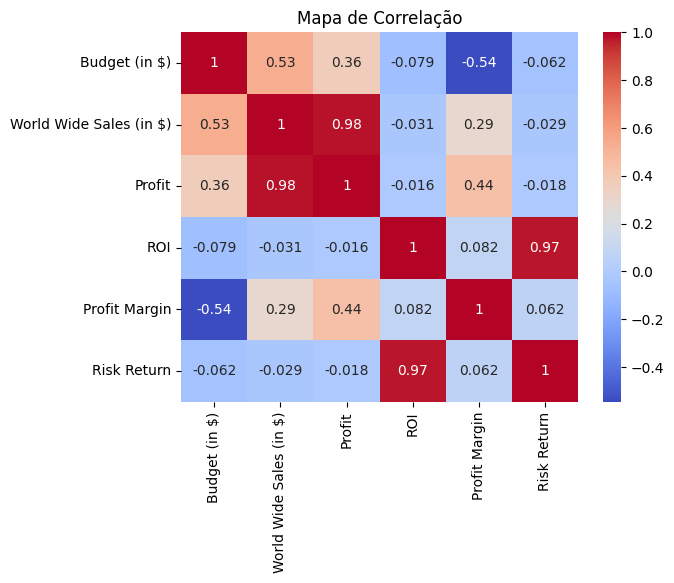

In [59]:
sns.heatmap(
    df[['Budget (in $)', 'World Wide Sales (in $)', 'Profit', 'ROI', 'Profit Margin', 'Risk Return']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Mapa de Correlação')
plt.show()

### Correlação logarítmica

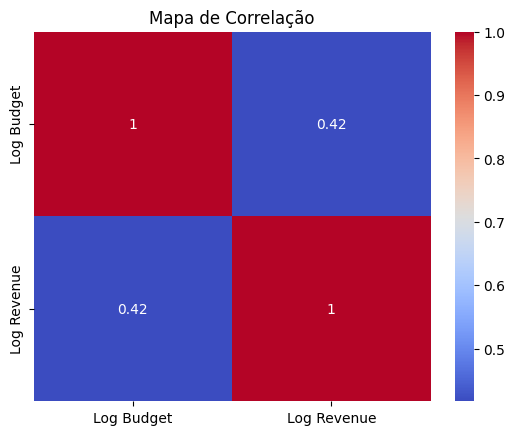

In [65]:
df['Log Budget'] = np.log(df['Budget (in $)'])
df['Log Revenue'] = np.log(df['World Wide Sales (in $)'])

sns.heatmap(
    df[['Log Budget', 'Log Revenue']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Mapa de Correlação')
plt.show()

## 📊 Visualização

A visualização permite observar padrões e possíveis relações entre as variáveis:

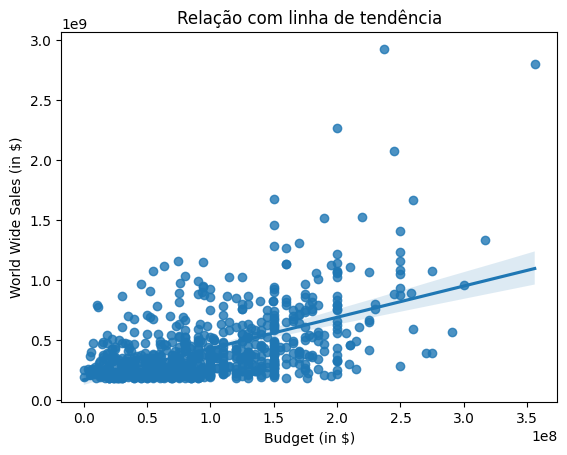

In [63]:
sns.regplot(x='Budget (in $)', y='World Wide Sales (in $)', data=df)
plt.title('Relação com linha de tendência')
plt.show()

## 📌 Análise por Faixa de Orçamento

Para entender como o retorno varia entre diferentes níveis de investimento:

In [64]:
df.groupby('Budget Category')['ROI'].median()

Budget Category
Low            8.255996
Medium         2.896446
High           2.179538
Blockbuster    2.059399
Name: ROI, dtype: float64

# ✅ Conclusão

A análise realizada permite identificar padrões importantes na relação entre o orçamento de um filme e seu desempenho financeiro.

Inicialmente, observa-se uma correlação positiva moderada (0.53) entre o orçamento (Budget) e a receita global (World Wide Sales). Esse resultado indica que, em média, filmes com maior investimento tendem a gerar maior arrecadação. No entanto, essa relação não é forte o suficiente para afirmar que o aumento do orçamento garante, por si só, um maior desempenho de bilheteria.

Quando analisamos o lucro (Profit), a correlação com o orçamento é ainda mais baixa (0.36), sugerindo que, embora filmes mais caros arrecadem mais, isso não necessariamente se traduz em maior lucro proporcional.

Por outro lado, a correlação entre receita e lucro é extremamente alta (0.98), o que é esperado, já que o lucro depende diretamente da receita obtida. Esse resultado reforça a consistência dos dados.

Um dos pontos mais relevantes da análise é a relação entre orçamento e eficiência do investimento. A correlação entre orçamento e ROI é ligeiramente negativa (-0.08), enquanto a correlação com a margem de lucro (Profit Margin) é moderadamente negativa (-0.54). Isso indica que filmes com maior orçamento tendem a ser menos eficientes em termos de retorno proporcional, ou seja, apesar de arrecadarem mais em valores absolutos, geram menor retorno relativo sobre o investimento.

A análise com transformação logarítmica confirma esse comportamento, apresentando uma correlação moderada (0.42) entre orçamento e receita, sugerindo uma relação positiva, porém não linear. Isso indica que o crescimento da receita não acompanha proporcionalmente o aumento do investimento.

Além disso, a segmentação por faixa de orçamento revela um padrão bastante expressivo: filmes de baixo orçamento apresentam um ROI médio extremamente elevado (96.04), enquanto filmes de médio, alto orçamento e blockbusters apresentam valores significativamente menores (entre aproximadamente 2.5 e 3.8). Esse resultado evidencia que filmes mais baratos possuem maior potencial de retorno proporcional, embora frequentemente com maior variabilidade e presença de outliers.

## 🎯 Síntese Final

Com base nos resultados, conclui-se que:

- Existe evidência de relação positiva entre orçamento e receita, mas de intensidade moderada  
- Filmes com maior orçamento tendem a gerar maior receita e lucro absoluto  
- No entanto, apresentam menor eficiência financeira (ROI e margem de lucro)  
- Filmes de baixo orçamento, embora mais arriscados, podem gerar retornos proporcionais muito superiores  

## 🧠 Interpretação Geral

Portanto, o investimento em grandes produções está associado a maior previsibilidade de receita, enquanto produções de baixo orçamento apresentam maior potencial de retorno relativo, porém com maior risco.
